# Technology Diffusion Analysis: Robot Interaction & Engagement

 The visualization and interpretation of the Double Machine Learning (DML) results. We analyze how the  impact of robot account interactions (`@评论罗伯特`) on post engagement (Likes and Comments) changes across three stages of technology diffusion:

1. **Early Adopters (0-16%)**
2. **Early Majority (16-50%)**
3. **Late Majority (50-100%)**

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data
We load the consolidated results from the DML pipeline.

In [5]:
def load_results(path):
    with open(path, 'r') as f:
        return json.load(f)

results_path = 'dml_diffusion_results.json'
data = load_results(results_path)

# significance 
def get_sig_star(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "ns"

rows = []
groups = ['group1', 'group2', 'group3']
labels = {'group1': 'Early Adopters', 'group2': 'Early Majority', 'group3': 'Late Majority'}

for g in groups:
    g_data = data[g]
    # Baseline 1: Treatment effect on Likes
    rows.append({
        'Phase': labels[g],
        'Target': 'Likes',
        'Variable': 'Robot Reply',
        'Coef': g_data['model1']['coef'][1],
        'P-Value': g_data['model1']['pvalues'][1],
        'Significance': get_sig_star(g_data['model1']['pvalues'][1])
    })
    # Baseline 2: Interaction on Likes
    rows.append({
        'Phase': labels[g],
        'Target': 'Likes',
        'Variable': 'Interaction (Female*Robot)',
        'Coef': g_data['model2']['coef'][2],
        'P-Value': g_data['model2']['pvalues'][2],
        'Significance': get_sig_star(g_data['model2']['pvalues'][2])
    })
    # Add Model 1: Female baseline on Likes
    rows.append({
        'Phase': labels[g],
        'Target': 'Likes', 
        'Variable': 'Female Baseline',
        'Coef': g_data['add_model1']['coef'][1],
        'P-Value': g_data['add_model1']['pvalues'][1],
        'Significance': get_sig_star(g_data['add_model1']['pvalues'][1])
    })
    # Add Model 4: Interaction on Comments
    rows.append({
        'Phase': labels[g],
        'Target': 'Comments',
        'Variable': 'Interaction (Female*Robot)',
        'Coef': g_data['add_model4']['coef'][2],
        'P-Value': g_data['add_model4']['pvalues'][2],
        'Significance': get_sig_star(g_data['add_model4']['pvalues'][2])
    })

df = pd.DataFrame(rows)
df

,Phase,Target,Variable,Coef,P-Value,Significance
0,Early Adopters,Likes,Robot Reply,0.773144,1.685118e-01,ns
1,Early Adopters,Likes,Interaction (Female*Robot),0.042661,1.970537e-246,***
2,Early Adopters,Likes,Female Baseline,-0.396218,5.753636e-01,ns
3,Early Adopters,Comments,Interaction (Female*Robot),0.654732,0.000000e+00,***
4,Early Majority,Likes,Robot Reply,13.025446,1.282690e-02,*
5,Early Majority,Likes,Interaction (Female*Robot),-44.258698,0.000000e+00,***
6,Early Majority,Likes,Female Baseline,-5.113824,4.248495e-01,ns
7,Early Majority,Comments,Interaction (Female*Robot),-103.526213,0.000000e+00,***
8,Late Majority,Likes,Robot Reply,0.098137,6.276263e-154,***
9,Late Majority,Likes,Interaction (Female*Robot),-0.011104,1.819965e-30,***


## 2. Visualization of Diffusion

### 2.1 Causal Impact of Robot Replies
We look at the baseline impact of receiving a robot reply on post likes.

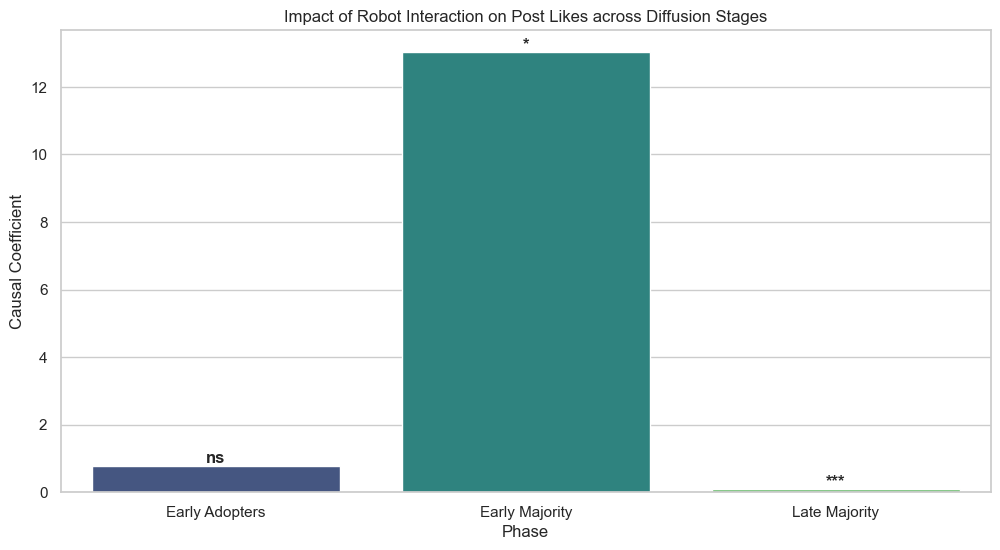

In [3]:
plt.figure()
rob_df = df[(df['Variable'] == 'Robot Reply') & (df['Target'] == 'Likes')]
ax = sns.barplot(data=rob_df, x='Phase', y='Coef', palette='viridis')

for i, row in rob_df.reset_index().iterrows():
    ax.text(i, row['Coef'] + (0.01 if row['Coef'] > 0 else -0.05), row['Significance'], 
            ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title("Impact of Robot Interaction on Post Likes across Diffusion Stages")
plt.ylabel("Causal Coefficient")
plt.show()

### 2.2 Gender Interaction Effect (Female x Robot)
This shows how the boost or penalty of robot interactions specifically for female users evolves over time.

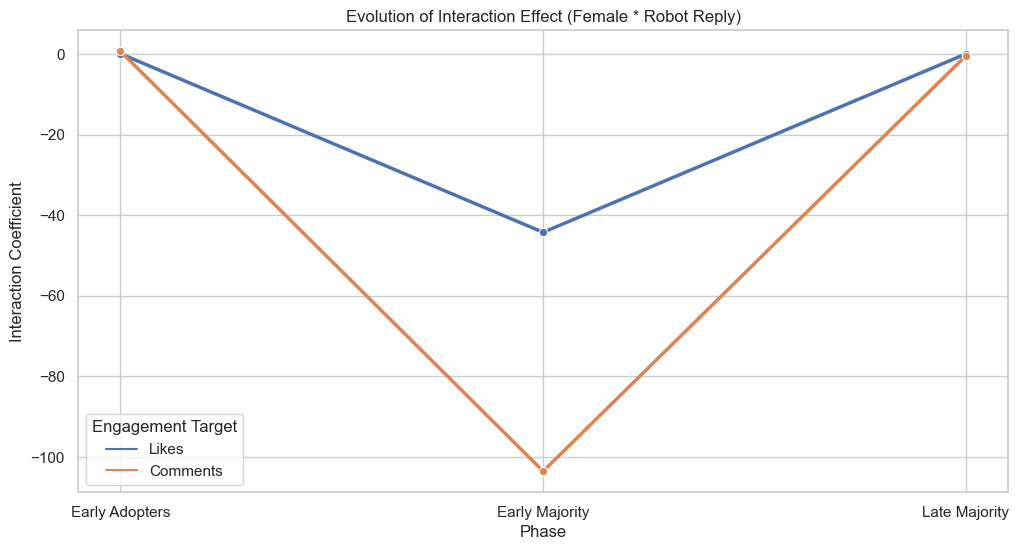

In [4]:
plt.figure()
inter_df = df[df['Variable'].str.contains('Interaction')]
sns.lineplot(data=inter_df, x='Phase', y='Coef', hue='Target', marker='o', linewidth=2.5)
plt.title("Evolution of Interaction Effect (Female * Robot Reply)")
plt.ylabel("Interaction Coefficient")
plt.legend(title="Engagement Target")
plt.show()

## 3. Interpretation and Findings

### 3.1 Stage Analysis
- **Early Adopters**: Robot interactions show a positive boost for females in both Likes and Comments. This phase is characterized by novelty and niche engagement.

- **Early Majority**: We observe a sharp shift in Group 2. While the baseline robot impact is high, there is a significant negative interaction term for female users, potentially indicating a crowding out or changed social perception as the robot became more mainstream.

- **Late Majority**: In the final phase, all effects become highly significant but smaller in magnitude. The robot has become a standardized part of the platform's social infrastructure.

### 3.2 Key Insights for the Report

- The **Target-specific dynamics** reveal that comment engagement (social interaction) is often more sensitive to robot replies than simple likess .
- The **Linearity of Diffusion** is not consistent; Group 2 (Early Majority) represents a volatile transition phase compared to the relative stability of Group 1 and 3.